<a href="https://colab.research.google.com/github/SamaviaJaffery/learning-normal-for-open-world-anomaly-detection-in-campus-cctv/blob/main/CourseProjectSamaviaJaffery_FIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# ----- PATH CONFIG -----
ROOT = "/content/drive/MyDrive/datasets/ShanghaiTech/extracted/shanghaitech"

TRAIN_VIDEO_ROOT = f"{ROOT}/training/videos"
TEST_FRAME_ROOT  = f"{ROOT}/testing/frames"
TEST_MASK_ROOT   = f"{ROOT}/testing/test_frame_mask"
WEAPON_ROOT      = f"{ROOT}/weapons"

TRAIN_FEATS_PATH  = f"{ROOT}/training/train_features_normal.npy"
TEST_FEATS_PATH   = f"{ROOT}/testing/test_features.npy"
WEAPON_FEATS_PATH = f"{ROOT}/weapons/weapon_feats.npy"


In [ ]:
#mounting drive to google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# loading important depedencies in the COLAB environment

!pip -q install transformers timm einops scikit-learn matplotlib av


In [ ]:
#***** DO NOT RUN THIS BLOCK******



#getting the weapon anomaly dataset
!pip install -q datasets pillow

from datasets import load_dataset

ds = load_dataset("Simuletic/cctv-weapon-dataset") #downloads the dataset into the current directory
print(ds)



README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/283 [00:00<?, ?it/s]

samples/images/Scene1_10.png:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

samples/images/Scene1_5.png:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

samples/images/Scene1_6.png:   0%|          | 0.00/998k [00:00<?, ?B/s]

...

samples/images/Scene6_8.png:   0%|          | 0.00/1.70M [00:00<?, ?B/s]

samples/images/Scene6_6.png:   0%|          | 0.00/1.70M [00:00<?, ?B/s]

samples/images/Scene6_9.png:   0%|          | 0.00/1.61M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/141 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image'],
        num_rows: 141
    })
})


In [ ]:
#**** DO NOT RUN THIS BLOCK *****************\




#Saving a few files into the folder
from pathlib import Path
from PIL import Image


weapon_root = Path(WEAPON_ROOT)
weapon_root.mkdir(parents=True, exist_ok=True) #if directory is not already available, it will make t

max_images = min(50, len(ds["train"]))

"""
Saves 50 images or fewer if the dataset has fewer than 50 images
from the Synthetic CCTV Weapons Dataset
"""

for i in range(max_images):
    row = ds["train"][i]
    img = row["image"]  # this is a PIL.Image
    if img.mode != "RGB": #if the image is not RGC convert it
        img = img.convert("RGB")
    img.save(weapon_root / f"weapon_{i:04d}.jpg")

print("Saved", max_images, "images to", weapon_root)


Saved 50 images to /content/drive/MyDrive/datasets/ShanghaiTech/extracted/shanghaitech/weapons


In [ ]:
# *******************DO NOT RUN*********************


#Extracted the Shanghai Tech Dataset from the tar files.

import os
from pathlib import Path

"""
Reconstructs the Shanghai Tech dataset from the multi-split available parts into a single file
in the out directory.

Note: This process is not required if the reconstructed dataset is already provided in the drive.

"""
#DIRECTORIES NEED TO BE CREATED IN THE DRIVE AND DATASET PLACE THERE
SPLIT_DIR = "/content/drive/MyDrive/datasets/ShanghaiTech/raw/splits_raw/splits" #where the raw splits dataset lives
OUT_DIR   = "/content/drive/MyDrive/datasets/ShanghaiTech/extracted" #where the extracted dataset will go


os.environ["SPLIT_DIR"] = SPLIT_DIR
os.environ["OUT_DIR"]   = OUT_DIR

!ls -lh "$SPLIT_DIR"/shanghaitech.tar.gz.a{a..g} #listing all the multi-part files to see if they look okay

!mkdir -p "$OUT_DIR" #making the output directory
!bash -lc 'cat "$SPLIT_DIR"/shanghaitech.tar.gz.a{a..g} | tar -xf - -C "$OUT_DIR"' #reconstructs all the split parts in the correct order
                                                                                   # and reconstructs one single file into Out directory

#sanity check
vids = [p for p in Path(OUT_DIR).rglob("*") if p.suffix.lower() in {".mp4",".avi",".mov",".mkv"}] #recursively walks through the videos
print("Videos found:", len(vids)) #generates the nuber of videos found
print(*vids[:10], sep="\n") #generates the length of the videos





-rw------- 1 root root 1.0G Nov 19 19:29 /content/drive/MyDrive/datasets/ShanghaiTech/raw/splits_raw/splits/shanghaitech.tar.gz.aa
-rw------- 1 root root 1.0G Nov 19 01:36 /content/drive/MyDrive/datasets/ShanghaiTech/raw/splits_raw/splits/shanghaitech.tar.gz.ab
-rw------- 1 root root 1.0G Nov 19 01:38 /content/drive/MyDrive/datasets/ShanghaiTech/raw/splits_raw/splits/shanghaitech.tar.gz.ac
-rw------- 1 root root 1.0G Nov 19 01:40 /content/drive/MyDrive/datasets/ShanghaiTech/raw/splits_raw/splits/shanghaitech.tar.gz.ad
-rw------- 1 root root 1.0G Nov 19 01:43 /content/drive/MyDrive/datasets/ShanghaiTech/raw/splits_raw/splits/shanghaitech.tar.gz.ae
-rw------- 1 root root 1.0G Nov 19 01:44 /content/drive/MyDrive/datasets/ShanghaiTech/raw/splits_raw/splits/shanghaitech.tar.gz.af
-rw------- 1 root root 526M Nov 19 01:46 /content/drive/MyDrive/datasets/ShanghaiTech/raw/splits_raw/splits/shanghaitech.tar.gz.ag
tar: Archive is compressed. Use -z option
tar: Error is not recoverable: exiting no

In [ ]:
#Helper function for preparing data for VIDEOMAE MODEL

import numpy as np
import av
from pathlib import Path
from PIL import Image
import torch

#to sample the .jpg test files from the Shanghai Test dataset
def extract_clip_features_from_frame_dir(
    frame_dir,
    clip_len,
    frame_sample_rate,
    stride: int,
):
    """
    The Shanghai Test Dataset includes .jpg files for the test instead of .avi videos.
    Therefore, a separate helper function is needed to perform this extraction.
    The frame_dir is given as an input, and several clips are extracted from a single frame.
    This increases the number of samples per video and allows us to look at more context.

    Note: Here, we capture the last hidden state instead of the output since that state has the
    most important semantic feature information for our case

    frame_dir: Path to folder containing .jpg frames of one video
    returns:
        features: np.ndarray of shape [num_clips, 768]  (or None if too few frames)
    """
    # Getting all frames in order
    frame_paths = sorted(frame_dir.glob("*.jpg"))
    num_frames = len(frame_paths)
    if num_frames < clip_len * frame_sample_rate: #don't use too small
        print(f"Skipping {frame_dir}, too few frames: {num_frames}")
        return None

    all_features = []

    # Slides a window through the frames: 0, stride, 2*stride, ...
    for start in range(0, num_frames - clip_len * frame_sample_rate + 1, stride):
        indices = list(range(start, start + clip_len * frame_sample_rate, frame_sample_rate)) #moves from start to start+(clip_length*frame_sample_rate)
        frames = [
            Image.open(frame_paths[i]).convert("RGB") #opens the image and converts it to RGB
            for i in indices
        ]

        # Preprocess and send to GPU
        inputs = image_processor(frames, return_tensors='pt') #AutoImageProcessor for VideoMae (it is a provided function).
        inputs = {k: v.to("cuda") for k, v in inputs.items()} #it returns a tensor and sends it to the GPU

        # VideoMAE to feature extraction
        with torch.no_grad():
            outputs = videomae(**inputs) #takes the clips as input
            last_hidden_state = outputs.last_hidden_state   # [1, seq_len, 768] The last hidden state captures the semantic information
            feat = last_hidden_state.mean(dim=1).squeeze(0) # [768]

        all_features.append(feat.cpu().numpy()) #convert them to numpy

    if len(all_features) == 0:
        return None


    return np.stack(all_features).astype(np.float32)   # [num_clips, 768]


#reading frames from the videos of the training data
def read_video_pyav(container, indices):
    """

    This helper function is specific to the training data in the Shanghai test dataset.
    The training data includes video in the .avi format as the normal training samples.
    This function uses the sampling indices and the container to extract clips from the videos

    input: Container, indices
    output: rgb clips

    """
    frames=[] #list to store frames

    container.seek(0) #making sure the video starts from the beginning

    #indices we read
    start_indx=indices[0]
    end_indx=indices[-1]

    #print('end_indice', end_indx)

    #decode all the frames from the first video
    for i, frame in enumerate (container.decode(video=0)):

      if i>end_indx:
        break #break if index passes the largest required index

      if i>=start_indx and i in indices:
         #if i exist in the indices
         frames.append(frame) #append the frame to the list
    #print('frames length pre stacking', len(frames))
    return np.stack([x.to_ndarray(format="rgb24") for x in frames]) #stack them into one big array



#build labels for existing test errors
def build_clip_labels_for_existing_test_errors(
    frames_root,
    mask_root,
    test_errors,
    clip_len=16,
    frame_sample_rate=1,
    stride=16,
):
    """
    This builds the labels for the Shanghai Tech TEST dataset using the already available test_frame_mask.npy files.
    It replicates the exact sliding window feature to generate the mask labels. This ensure that the annotations are matching correctly.

    Mask 0 is normal activity and mask 1 is abnormalities.

    IMPORTANT: THE CLIP EXTRACTION FOR TEST DATA AND TEST MASK MUST MATCH

    frames_root: path to testing/frames/
    mask_root:   path to testing/test_frame_mask/
    test_errors: numpy array in the same order as features were extracted
    """
    frames_root = Path(frames_root) #path to the test files
    mask_root   = Path(mask_root) #path to the masked files

    video_dirs = sorted([p for p in frames_root.iterdir() if p.is_dir()]) #sorting videos in order
    print("number of test videos:", len(video_dirs))

    labels = []
    meta=[]
    clip_idx = 0

    for vid_dir in video_dirs:
        vid_id = vid_dir.name  # e.g. '01_0014'
        frame_paths = sorted(vid_dir.glob("*.jpg")) #sorting the images inside the directory
        num_frames = len(frame_paths) #calculating the total number of frames

        if num_frames < clip_len * frame_sample_rate: #if there are too little frames then stop
            print("Skipping short video:", vid_id)
            continue

        # load mask for this video
        mask_path = mask_root / f"{vid_id}.npy" #load masks from the root file
        mask = np.load(mask_path)  # [num_frames], usually 0/1
        mask = (mask > 0).astype(np.uint8)


        print("Aligning video:", vid_id, "num_frames:", num_frames)

        for start in range(0, num_frames - clip_len * frame_sample_rate + 1, stride): # replicate the exact sliding window used in feature extraction

            indices = np.arange(
                start,
                start + clip_len * frame_sample_rate,
                frame_sample_rate,
            )  # 16 frame indices


            if clip_idx >= len(test_errors):
                raise ValueError("More clips computed than test_errors length!")


            clip_label = int(mask[indices].max() > 0) # label: 1 if ANY frame in the clip is anomalous
            labels.append(clip_label) #add them to a list


            meta.append((vid_id, int(start)))   #storing meta information for the clip

            clip_idx += 1 #update the index

    if clip_idx != len(test_errors):
        print("WARNING: mismatch between number of labels and errors!",
              "labels:", clip_idx, "errors:", len(test_errors))

    labels = np.array(labels, dtype=np.int64) #returned as numpy arrays
    print("Built labels for", len(labels), "clips.")
    return labels, meta



#extract features for the WEAPONS TEST DATASET
def extract_weapon_clip_features(
    weapon_root,
    clip_len=16,
    max_images=50,  # limit for speed
):
    """
    This is the test dataset for the weapon based anomaly. The data includes campus footage with people holding
    weapons, the anomaly is passed through the VideoMAE model and features are extracted.

    Since the data is in the form of the input, several clips are sampled from the same image to create a similar structure
    to our training dataset.

    input: folder containing weapon images (jpg/png).
    output: numpy of shape [N_clips, 768]
    """

    weapon_root = Path(weapon_root)
    image_paths = sorted(  #sorts all the images into a reproducible order
        list(weapon_root.glob("*.jpg")) +
        list(weapon_root.glob("*.png")) +
        list(weapon_root.glob("*.jpeg"))
    )

    if len(image_paths) == 0:  #if no images are found, returns nothing
        print("No weapon images found in", weapon_root)
        return None


    image_paths = image_paths[:max_images]  #This limits the number of images
    print("Using", len(image_paths), "weapon images")

    all_features = []

    for img_path in image_paths:
        img = Image.open(img_path).convert("RGB") #opens the images and conver to RGB (3 channels)

        frames = [img] * clip_len # repeat same frame clip_len times

        inputs = image_processor(frames, return_tensors='pt') #This is ImageProccessor from the VideoMAE module
        inputs = {k: v.to("cuda") for k, v in inputs.items()} #sends the tensor to the GPU

        with torch.no_grad():
            outputs = videomae(**inputs)
            last_hidden_state = outputs.last_hidden_state  # [1, T, 768] #extracts the last hidden state as it has the most important semantic information
            feat = last_hidden_state.mean(dim=1).squeeze(0)  # [1, 768]  #squeeze the token sequence

        all_features.append(feat.cpu().numpy()) #move features to cpu and convert to the numpy module

    weapon_feats = np.stack(all_features).astype(np.float32) #stack features together
    np.save(WEAPON_FEATS_PATH, weapon_feats) #Save the clips in the google drive
    print("weapon_features shape:",  weapon_feats.shape)  # [N_clips, 768]
    return  weapon_feats


In [ ]:
#extracting features for each test video
from transformers import VideoMAEModel, AutoImageProcessor
import torch.nn as nn
import torch
from pathlib import Path

#loading the base model
videomae=VideoMAEModel.from_pretrained("MCG-NJU/videomae-base")
videomae.to(device="cuda")
image_processor=AutoImageProcessor.from_pretrained("MCG-NJU/videomae-base") #convert the frames into images for forward pass

def extracting_features_from_each_test_video(test_root):

  """
  This function assumes the ShanghaiTech TEST set has already been
      extracted into per-video frame folders.

      For each video directory, it calls `extract_clip_features_from_frame_dir`
      and slides a temporal window over the frames, forms clips of clip-length, run each clip through VIDEOMAE
      and product a 768 feature vector/clip

  """


  test_root=Path(test_root) #the path
  video_dirs = sorted([p for p in test_root.iterdir() if p.is_dir()]) #lists all the subdirectories
  print("number of test videos:", len(video_dirs))

  test_feature_per_video=[]

  #loops over each video folder
  for video_dir in video_dirs:
    print("extracting from:", video_dir)
    features=extract_clip_features_from_frame_dir(video_dir, clip_len=16, frame_sample_rate=1, stride=16) #extracting features per video clip
    if features is not None: #if the feature is present
     test_feature_per_video.append(features) #append it to the list of all the feature vectors



  print("Got features for", len(test_feature_per_video), "videos")
  test_features=np.concatenate(test_feature_per_video, axis=0).astype(np.float32) #[total clips, 768] concatenate features from all the videos along the first axis
  np.save("test_features.npy", test_features) #save in the current directory
  np.save(TEST_FEATS_PATH, test_features) #save in the following directory
  return test_features



In [ ]:
#***** DO NOT RUN THIS BLOCK **********************************



#USING VIDEOMAE FEATURE DETECTOR FOR SHANGHAI TECH TRAINING DATASET

from transformers import VideoMAEModel, AutoImageProcessor
import torch.nn as nn
import torch
from pathlib import Path

"""
This iterates over all the normal training videos (.avi files) and slices each video into clips.
clip length is 16, frame_sample_rate is 1 and the stride is 16. For each clips:
-it reads the corresponding frames with pyAV
-use the pretrained model VIDEOMAE to extract features
-stack it into a single numpy array and save features to the list
"""
#loading the base model
videomae=VideoMAEModel.from_pretrained("MCG-NJU/videomae-base") #loading videomae model
videomae.to(device="cuda") #sending the model to GPU
image_processor=AutoImageProcessor.from_pretrained("MCG-NJU/videomae-base") #convert the frames into images for forward pass

root_dir=Path(TRAIN_VIDEO_ROOT)


video_paths=sorted(root_dir.rglob("*.avi")) #getting all the .avi files recursively
print('number of videos', len(video_paths))
clip_len = 16 #number of frames/clip
frame_sample_rate = 1 #use every frame
stride = 16 #step size between clip starts
all_features=[]

# extracting the features from all the videos
for video_path in video_paths:
    print("extracting from:", video_path)
    container = av.open(str(video_path))
    num_frames = int(container.streams.video[0].frames)

    # skip super short videos
    if num_frames < clip_len * frame_sample_rate:
        print("Skipping (too short):", video_path, "num_frames:", num_frames)
        continue

    # slide: 0, stride, 2*stride, ...
    for start in range(0, num_frames - clip_len * frame_sample_rate + 1, stride): # Each window covers clip_len * frame_sample_rate frames.
        indices = np.arange(start,
                            start + clip_len * frame_sample_rate,
                            frame_sample_rate)

        # getting the frames of the video for this clip
        frames = read_video_pyav(container, indices)

        inputs = image_processor(list(frames), return_tensors="pt")
        inputs = {k: v.to("cuda") for k, v in inputs.items()}

        # one forward pass
        with torch.no_grad():
            output = videomae(**inputs)

        last_hidden_state = output.last_hidden_state      # [1, T, 768] #most important layer for the semantic information
        feat = last_hidden_state.mean(dim=1).squeeze(0)   # [768]
        all_features.append(feat.cpu().numpy())           # collect per-clip feature

# stack all clip features
train_features = np.stack(all_features).astype(np.float32)
print("train_features shape:", train_features.shape)  # [N_clips, 768]

# save
np.save("train_features_normal.npy", train_features)  # current directory
np.save(
    TRAIN_FEATS_PATH,
    train_features)


number of videos 330
extracting from: /content/drive/MyDrive/datasets/ShanghaiTech/extracted/shanghaitech/training/videos/01_001.avi
extracting from: /content/drive/MyDrive/datasets/ShanghaiTech/extracted/shanghaitech/training/videos/01_002.avi
extracting from: /content/drive/MyDrive/datasets/ShanghaiTech/extracted/shanghaitech/training/videos/01_003.avi


KeyboardInterrupt: 

In [ ]:
#AutoEncoder Module


import time
import torch
import torch.nn as nn
import torch.nn.functional as F


class MemoryModule(nn.Module):
    def __init__(self, mem_size=50, feat_dim=128):
        super().__init__()
        # memory items: K x D
        self.memory = nn.Parameter(torch.randn(mem_size, feat_dim))

    def forward(self, z):
        """
        z: [B, D] latent features from encoder
        returns:
            z_hat: [B, D] memory-augmented latent
            attn: [B, K] attention weights over memory items
        """
        # cosine similarity (or dot product)
        # z: [B, D], memory: [K, D] -> [B, K]
        z_norm = F.normalize(z, dim=1)
        mem_norm = F.normalize(self.memory, dim=1)
        attn = torch.matmul(z_norm, mem_norm.t())  # [B, K]

        # softmax over memory dimension
        attn = F.softmax(attn, dim=1)  # [B, K]

        # weighted sum of memory items: [B, K] x [K, D] -> [B, D]
        z_hat = torch.matmul(attn, self.memory)
        return z_hat, attn

#encoder class
"""
The encoder class consists of
4 linear layers and relu activations in between
"""

class Encoder(nn.Module):
    def __init__(self, mode):
        super(Encoder, self).__init__()

        #for model
        self.fc1=nn.Linear(768, 512); # linear layer converts 768-> 512
        self.fc2=nn.Linear(512, 256); # linear layer converts 512-> 256
        self.fc3=nn.Linear(256, 128); # linear layer converts 256-> 128
        #self.fc4=nn.Linear(128, 64); # linear layer converts 128-> 64



        if mode == 1:
            self.forward = self.model
        else:
            print("Invalid mode ", mode, "selected. Select between 1-2")
            exit(0)

    def model(self, X):

        fc1 = F.relu(self.fc1(X)) #linear layer +ReLu activation 784 ->
        fc2 = F.relu(self.fc2(fc1)) #linear layer + ReLu activation
        fc3 = F.relu(self.fc3(fc2)) #linear layer + ReLu activation
        #print("Size of encoder output:", fc2_enc.size())
        return fc3





#decoder class
"""
The decoder class consists of
4 linear layers and relu activations in between.
"""

class Decoder(nn.Module):
    def __init__(self, mode):
        super(Decoder, self).__init__()

        #first model (Linear Layers)
        #self.fc1=nn.Linear(64, 128); # linear layer converts 64->128
        self.fc2=nn.Linear(128, 256); # linear layer converts 128 -> 256
        self.fc3=nn.Linear(256, 512); # linear layer converts 256-> 512
        self.fc4=nn.Linear(512, 768); # linear layer converts  512->768




        if mode == 1:
            self.forward = self.model_1
        else:
            print("Invalid mode ", mode, "selected. Select between 1-2")
            exit(0)

    def model_1(self, X):

        #gets the flattened input

        #fc1 = F.relu((self.fc1(X))) #linear layer +ReLu activation 64 -> 128
        fc2 = F.relu((self.fc2(X))) #linear layer +ReLu activation
        fc3 = F.relu((self.fc3(fc2))) #linear layer +ReLu activation
        fc4 = (self.fc4(fc3)) #linear layer +ReLu activation
        return fc4


#Autoencoder Class

"""
The Autoencoder class is the main class that instantiates the encoder
and decoder class to generate the output. It also includes the memory module
to get the z_hat (memory protype) and attn scores.

"""

class AutoEncoder(nn.Module):
    def __init__(self, mode):
        super(AutoEncoder, self).__init__()

        self.encoder=Encoder(mode) #instantiate the encoder
        self.decoder=Decoder(mode) #instantiate the decoder
        self.memory_module=MemoryModule() #instantiate the memory module
    def forward(self, X):

        z=self.encoder(X) #Take the input and encode it
        z_hat, attn=self.memory_module(z) #apply the memory module and get latents and attn scores
        r=self.decoder(z_hat) #Take the encoder output and decode the results
        return r, z, z_hat, attn

In [ ]:
def entropy_loss(attn, eps=1e-8):
    """
    It is the shannon attention, which says if:

    High entropy= spread out attn
    low entropy= clustered attn
    since it is used as a loss function, it tries to keep the entropy low and
    cluster the memory prototype.



    attn:attention weights (softmax outputs)
    returns average entropy per sample
    """
    # avoid log(0)
    attn_clamped = torch.clamp(attn, eps, 1.0)
    ent = -torch.sum(attn_clamped * torch.log(attn_clamped), dim=1)  # using the k= ∑​ak * ​log(ak​)
    return ent.mean()


In [ ]:
#training class
from __future__ import print_function
import argparse
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
import argparse
import numpy as np
import matplotlib.pyplot as plt


def train(model, device, train_loader, optimizer, criterion, epoch, batch_size):
    '''
    Trains the model for an epoch and optimizes it.
    model: The model to train. Should already be in correct device.
    device: 'cuda' or 'cpu'.
    train_loader: dataloader for training samples.
    optimizer: optimizer to use for model parameter updates.
    criterion: used to compute loss for prediction and target, and also for reconstruction and memory latents (z_hat)
    epoch: Current epoch to train for.
    batch_size: Batch size to be used.
    '''

    # Set model to train mode before each epoch
    model.train()

    # Empty list to store losses
    losses = []
    correct = 0

    #hyperparameters
    lambda_compact= 0.1 #weights for making z_hat and z close to another
    lambda_sparse= 0.0002 #weights for sparsity of the protype latents (how specialized or clustered they should be)

    # Iterate over entire training samples (1 epoch)
    for batch_idx, (batch_sample,) in enumerate(train_loader):
        data = batch_sample

        # Push data/label to correct device
        data = data.to(device)

        #print("size of target", target.size())
        #print("size of data", data.size())

        # Reset optimizer gradients. Avoids grad accumulation
        optimizer.zero_grad()

        # Do forward pass for current set of data
        recon, z, z_hat, attn = model(data)
        #print("size of output", output.size())

        #computes loss based on criterion
        loss_recon = criterion(recon, data)
        #print("loss_recon", loss_recon)

        #compute the loss between z_hat and z to ensure they are closer together
        loss_compact=criterion(z_hat, z)
        #print("loss_compact", loss_compact)

        #compute entropy loss to ensure it stays low
        loss_sparse=entropy_loss(attn)
        #print("loss_sparse", loss_sparse)

        #create a sum of all the losses to backpropogate through the gradients
        loss=loss_recon+lambda_compact*loss_compact +lambda_sparse*loss_sparse


       # Computes gradient based on final loss
        loss.backward()

        # Store loss
        losses.append(loss.item())

        # Optimize model parameters based on learning rate and gradient
        optimizer.step()

    train_loss = float(np.mean(losses)) #get the mean loss
    print(f'epoch: {epoch}')
    msg='Train set: Average loss: {:.4f}\n'.format(train_loss) #print loss and epoch

    #Plotting the train_loss to show it's doing well
    print(msg)
    return train_loss

In [ ]:
#test file
import matplotlib.pyplot as plt

def test(model, device, test_loader, criterion, mode):
    '''
    Tests the model.
    Called twice, once for Shanghai Test data which helps in selecting a threshold
    Secondly for the anomaly detection which helps in detecting weapon anomalies


    model: The model to train. Should already be in correct device.
    device: 'cuda' or 'cpu'.
    test_loader: dataloader for test samples.
    '''

    # Set model to eval mode to notify all layers.
    model.eval()

    errors=[]


    # Set torch.no_grad() to disable gradient computation and backpropagation
    with torch.no_grad():
        for batch_indx, (sample,) in enumerate(test_loader):
            data= sample  #

            # Push data/label to correct device
            data= data.to(device)


            # Predict for data by doing forward pass
            recon, z, z_hat, attn = model(data) #obtains reconstruction, latents and attention score too

            #batch error
            batch_error=((recon-data)**2).mean(dim=1) #getting the reconstruction error
            errors.append(batch_error.cpu().numpy())

    test_errors=np.concatenate(errors, axis=0) #concatenating the error across the first dimension
    mean_error=test_errors.mean() #getting the mean error
    msg='\nTest set: Average loss: {:.4f}\n'.format(
        mean_error)
    print(msg)
    #log_line(msg)
    return test_errors

epoch: 1
Train set: Average loss: 0.0389

epoch: 2
Train set: Average loss: 0.0107

epoch: 3
Train set: Average loss: 0.0081

epoch: 4
Train set: Average loss: 0.0063

epoch: 5
Train set: Average loss: 0.0049

epoch: 6
Train set: Average loss: 0.0041

epoch: 7
Train set: Average loss: 0.0033

epoch: 8
Train set: Average loss: 0.0027

epoch: 9
Train set: Average loss: 0.0025

epoch: 10
Train set: Average loss: 0.0022

epoch: 11
Train set: Average loss: 0.0018

epoch: 12
Train set: Average loss: 0.0016

epoch: 13
Train set: Average loss: 0.0014

epoch: 14
Train set: Average loss: 0.0013

epoch: 15
Train set: Average loss: 0.0012

epoch: 16
Train set: Average loss: 0.0012

epoch: 17
Train set: Average loss: 0.0011

epoch: 18
Train set: Average loss: 0.0011

epoch: 19
Train set: Average loss: 0.0011

epoch: 20
Train set: Average loss: 0.0011

epoch: 21
Train set: Average loss: 0.0011

epoch: 22
Train set: Average loss: 0.0011

epoch: 23
Train set: Average loss: 0.0011

epoch: 24
Train set:

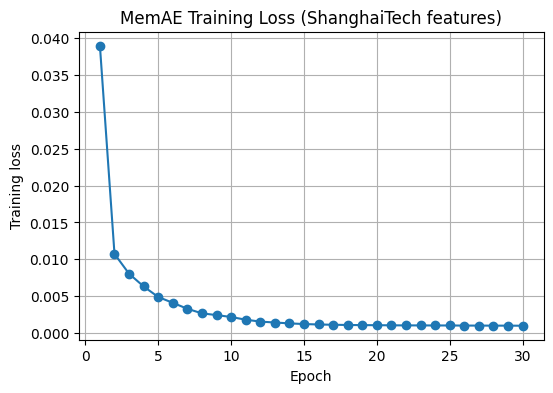

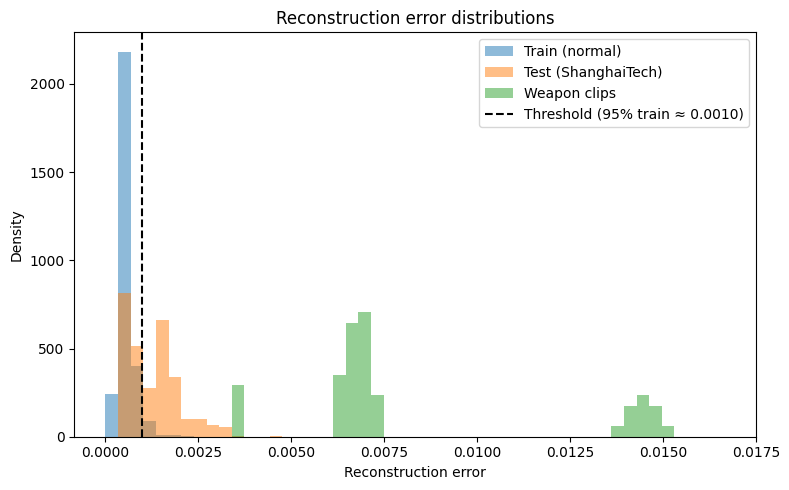

In [ ]:
#main file
"""
The main file calls the test and train logic to perform the learning,
defines the loss and optimizer
"""
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

def run_main(FLAGS):
    # Check if cuda is available
    use_cuda = torch.cuda.is_available()

    # Set proper device based on cuda availability
    device = torch.device("cuda" if use_cuda else "cpu")

    #log_line(f"Torch device selected: {device}")

    # Initialize the model and send to device
    model = AutoEncoder(FLAGS.mode).to(device)



    #criterion for loss
    criterion = nn.MSELoss()


    #Adam as an optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=FLAGS.learning_rate)



    # transforms to apply to each datasample [0,1] pixel work better with MSE
    transform=transforms.Compose([
        transforms.ToTensor()
        ])

    # Loads datasets for training and testing
    X_train = np.load(TRAIN_FEATS_PATH)  # [N, 768]
    X_train_t = torch.from_numpy(X_train).float()

    dataset_train = TensorDataset(X_train_t)

    #extracting features for the test_videos

    #***ONLY LEARN THESE IF THE VIDEOS FEATURES ARE NOT ALREADY DETECTED***

    # extracting_features_from_each_test_video(TEST_FRAME_ROOT)

    #extract_weapon_clip_features(
     #   WEAPONS_FEAT_PATH,
      #  clip_len=16,
       # max_images=50)   # or fewer if slow


    X_test = np.load(TEST_FEATS_PATH)  # [N, 768]
    X_test_t = torch.from_numpy(X_test).float()

    dataset_test = TensorDataset(X_test_t)

    #creating dataloaders
    train_loader = DataLoader(dataset_train, batch_size = FLAGS.batch_size,
                                shuffle=True, num_workers=2)
    test_loader = DataLoader(dataset_test, batch_size = FLAGS.batch_size,
                                shuffle=False, num_workers=2)



    train_losses=[]

    #**EVALUATING THE TRAINING SET***
    for epoch in range(1, FLAGS.num_epochs + 1):
        train_loss= train(model, device, train_loader,
                                            optimizer, criterion, epoch, FLAGS.batch_size) #evaluating the training set

        train_losses.append(train_loss)

    train_error= test(model, device, train_loader, criterion, FLAGS.mode) #sending mode to the test loss function

    print("Train mean:", train_error.mean())
    print("Train min/max:", train_error.min(), train_error.max())


    #evaluation on test set
    # Runs training for n_epochs specified in config
    #model.load_state_dict(torch.load("/content/drive/MyDrive/memae_video_features.pth", map_location=device))

    #***Evaluating the subdomain test set errors***
    test_errors= test(model, device, test_loader, criterion, FLAGS.mode)

    print("test mean:", test_errors.mean())
    print("test min/max:", test_errors.min(), test_errors.max())
    print("Train percentiles:", np.percentile(train_error, [50, 90, 95, 99]))
    print("Test  percentiles:", np.percentile(test_errors,  [50, 90, 95, 99]))

    #setting a threshold and comparing the performance with the masks
    thresh = np.percentile(train_error, 95)




    #EVALUATING THE TRUE ANOMALY SET (WEAPONS)

    weapon_test=np.load(WEAPON_FEATS_PATH)
    W_test_t = torch.from_numpy(weapon_test).float()

    dataset_test2 = TensorDataset(W_test_t)
    test_loader2 = DataLoader(dataset_test2, batch_size = FLAGS.batch_size,
                                shuffle=False, num_workers=2)
    if weapon_test is not None:
        weapon_errors = test(
            model, device, test_loader2, criterion, FLAGS.mode
        )

        print("Weapon mean error:", weapon_errors.mean())
        print("Weapon min/max:", weapon_errors.min(), weapon_errors.max())
        print("Weapon percentiles:", np.percentile(weapon_errors, [50, 90, 95, 99]))

        # fraction of weapon clips above the SAME unsupervised threshold
        frac_weapon_flagged = (weapon_errors > thresh).mean()
        print("Fraction of weapon clips flagged as anomaly:", frac_weapon_flagged)

    #PLOTTING
    #Plotting the training loss
    epochs = range(1, FLAGS.num_epochs + 1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs, train_losses, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("MemAE Training Loss (ShanghaiTech features)")
    plt.grid(True)
    plt.show()


    #Plotting the histogram for Train, in-domain anomalies and weapons anomalies
    plt.figure(figsize=(8, 5))

    bins = np.linspace(0, max(test_errors.max(), weapon_errors.max()) * 1.1, 50)

    plt.hist(train_error, bins=bins, alpha=0.5, label="Train (normal)", density=True)
    plt.hist(test_errors, bins=bins, alpha=0.5, label="Test (ShanghaiTech)", density=True)
    plt.hist(weapon_errors, bins=bins, alpha=0.5, label="Weapon clips", density=True)

    plt.axvline(thresh, color='k', linestyle='--', label=f"Threshold (95% train ≈ {thresh:.4f})")

    plt.xlabel("Reconstruction error")
    plt.ylabel("Density")
    plt.title("Reconstruction error distributions")
    plt.legend()
    plt.tight_layout()
    plt.show()

"""

Selects the arguments and training parameters for the model.
The choices are made by the user at the start of each training.

"""
if __name__ == '__main__':

    parser = argparse.ArgumentParser('CNN Exercise.')
    parser.add_argument('--mode',
                        type=int, default=1,
                        help='Select mode between 1-2.')
    parser.add_argument('--learning_rate',
                        type=float, default=1e-3,
                        help='Initial learning rate.')
    parser.add_argument('--num_epochs',
                        type=int,
                        default=30,
                        help='Number of epochs to run trainer.')
    parser.add_argument('--batch_size',
                        type=int, default=128,
                        help='Batch size. Must divide evenly into the dataset sizes.')
    parser.add_argument('--log_dir',
                        type=str,
                        default='logs',
                        help='Directory to put logging.')

    FLAGS = None
    FLAGS, unparsed = parser.parse_known_args()

    run_main(FLAGS)